# Notebook 04: Entrenamiento del Meta-Modelo (LightGBM) - Stacking Híbrido con Entropía

Este notebook cubre las siguientes etapas metodológicas de la tesis:
*   **Paso 11**: Entrenamiento del meta-modelo de Nivel 1 (**LightGBM**) utilizando el conjunto de meta-características (probabilidades + entropía de Shannon) generado por los modelos base de Nivel 0.
*   **Paso 12**: Evaluación e interpretación de la importancia de meta-características del Stacking Híbrido frente a los modelos base individuales sobre el conjunto de prueba aislado.

### Metodología del Meta-Modelo:
El meta-modelo (LightGBM) se entrena usando el dataset de meta-features `X_train_meta.csv` y se optimiza mediante búsqueda en cuadrícula (`GridSearchCV`) maximizando el **F1-Macro**.

In [1]:
import os
import pandas as pd
import numpy as np
import json
import joblib
import time
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Ajustar directorio de trabajo si es necesario
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print(f"Directorio de trabajo activo: {os.getcwd()}")

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
os.makedirs("results/figures", exist_ok=True)
os.makedirs("models", exist_ok=True)

Directorio de trabajo activo: /home/carmen/tesis_iot


In [2]:
# Cargar las meta-características de entrenamiento, validación y prueba
print("Cargando datasets de meta-características...")
X_train_meta = pd.read_csv("data/processed/X_train_meta.csv")
y_train_meta = pd.read_csv("data/processed/y_train_meta.csv").values.ravel()

X_val_meta = pd.read_csv("data/processed/X_val_meta.csv")
y_val_meta = pd.read_csv("data/processed/y_val_meta.csv").values.ravel()

X_test_meta = pd.read_csv("data/processed/X_test_meta.csv")
y_test_meta = pd.read_csv("data/processed/y_test_meta.csv").values.ravel()

with open("results/label_mapping.json", "r") as f:
    label_mapping = json.load(f)
class_names = [k for k, v in sorted(label_mapping.items(), key=lambda item: item[1])]

print(f"Meta-features Entrenamiento: {X_train_meta.shape[0]:,} muestras, {X_train_meta.shape[1]} columnas")
print(f"Meta-features Validación: {X_val_meta.shape[0]:,} muestras")
print(f"Meta-features Prueba: {X_test_meta.shape[0]:,} muestras")

Cargando datasets de meta-características...
Meta-features Entrenamiento: 483,940 muestras, 27 columnas
Meta-features Validación: 377,382 muestras
Meta-features Prueba: 377,383 muestras


## Paso 11: Optimización y Entrenamiento del Meta-Modelo (LightGBM)

Usamos `GridSearchCV` para encontrar los parámetros óptimos del meta-modelo LightGBM buscando maximizar el desempeño global sobre clases minoritarias.

In [3]:
print("Configurando Grid Search para el Meta-Clasificador LightGBM...")
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 4, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'verbosity': [-1]
}

meta_lgb = lgb.LGBMClassifier(random_state=42, n_jobs=2)
grid_search = GridSearchCV(
    estimator=meta_lgb, 
    param_grid=param_grid, 
    scoring='f1_macro', 
    cv=3, 
    verbose=1
)

start_time = time.time()
grid_search.fit(X_train_meta, y_train_meta)
print(f"Tuning del Meta-Modelo finalizado en {time.time() - start_time:.2f} segundos.")
print(f"Mejores parámetros encontrados: {grid_search.best_params_}")

best_meta_lgb = grid_search.best_estimator_
# Guardar el meta-modelo
joblib.dump(best_meta_lgb, "models/meta_lightgbm.pkl")
print("Meta-modelo guardado en 'models/meta_lightgbm.pkl'")

Configurando Grid Search para el Meta-Clasificador LightGBM...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
Tuning del Meta-Modelo finalizado en 463.78 segundos.
Mejores parámetros encontrados: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100, 'verbosity': -1}
Meta-modelo guardado en 'models/meta_lightgbm.pkl'


## Paso 12: Evaluación del Stacking Híbrido Propuesto (Sobre Prueba)

Evaluamos el Stacking Híbrido sobre el conjunto de prueba aislado y graficamos la matriz de confusión.

In [4]:
print("Evaluando el modelo Stacking Híbrido sobre el conjunto de prueba...")
test_preds = best_meta_lgb.predict(X_test_meta)

acc_stacking = accuracy_score(y_test_meta, test_preds)
print(f"Accuracy del Stacking Híbrido: {acc_stacking*100:.2f}%")

print("\nReporte de Clasificación del Stacking Híbrido (Prueba):")
report_stacking = classification_report(y_test_meta, test_preds, target_names=class_names, output_dict=True)
print(classification_report(y_test_meta, test_preds, target_names=class_names))

# Guardar reporte en CSV
df_report_stacking = pd.DataFrame(report_stacking).transpose()
df_report_stacking.to_csv("results/reporte_stacking_hibrido.csv")

Evaluando el modelo Stacking Híbrido sobre el conjunto de prueba...
Accuracy del Stacking Híbrido: 84.85%

Reporte de Clasificación del Stacking Híbrido (Prueba):
              precision    recall  f1-score   support

      Benign       0.65      0.61      0.63     18791
 Brute Force       0.45      0.39      0.41      1878
        DDoS       0.88      0.92      0.90    148475
         DoS       0.75      0.65      0.70     51945
       Mirai       1.00      1.00      1.00     55436
       Recon       0.78      0.88      0.82     62247
    Spoofing       0.87      0.75      0.81     35055
   Web-based       0.46      0.27      0.34      3556

    accuracy                           0.85    377383
   macro avg       0.73      0.68      0.70    377383
weighted avg       0.85      0.85      0.85    377383



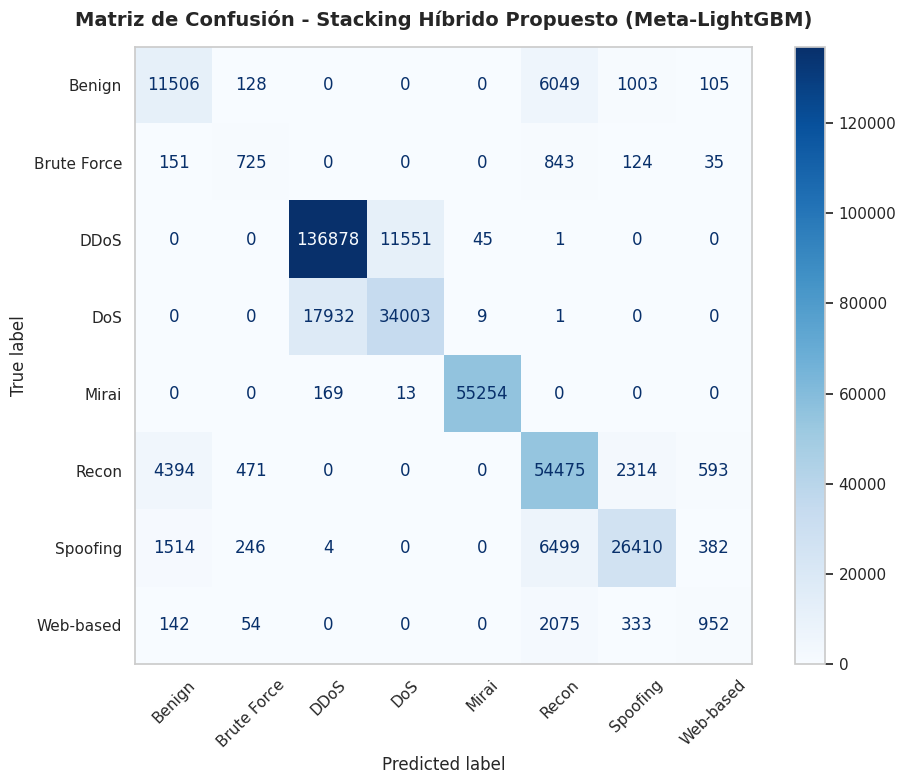

In [5]:
# Graficar la matriz de confusión del Stacking Híbrido
cm = confusion_matrix(y_test_meta, test_preds)
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', values_format='d', ax=plt.gca(), xticks_rotation=45)
plt.title("Matriz de Confusión - Stacking Híbrido Propuesto (Meta-LightGBM)", fontsize=14, fontweight='bold', pad=15)
plt.grid(False)
plt.tight_layout()
plt.savefig("results/figures/16_matriz_confusion_stacking_hibrido.png", dpi=300)
plt.show()

## Explicabilidad del Meta-Modelo: Importancia de Características

Analizamos la importancia relativa de las meta-features (probabilidades de clase y entropías de Shannon de los clasificadores de Nivel 0) para entender cuáles guiaron más la predicción final.

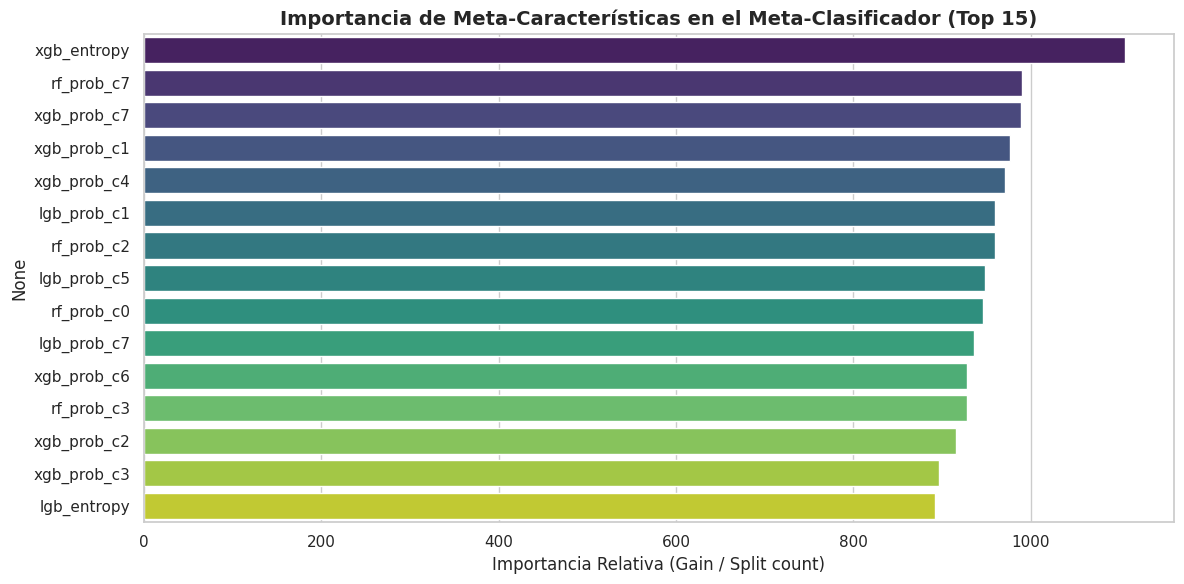

In [6]:
importances = best_meta_lgb.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
sns.barplot(x=importances[indices[:15]], y=X_train_meta.columns[indices[:15]], palette='viridis', hue=X_train_meta.columns[indices[:15]], legend=False)
plt.title("Importancia de Meta-Características en el Meta-Clasificador (Top 15)", fontsize=14, fontweight='bold')
plt.xlabel("Importancia Relativa (Gain / Split count)")
plt.tight_layout()
plt.savefig("results/figures/17_importancia_meta_modelo.png", dpi=300)
plt.show()